# DatOps Forensic EDA — Track 3 AgriTech

This notebook is the evidence trail behind the DatOps analytical layer.

The goal is **not** to make the raw data look clean. The goal is to show what was wrong, what can be repaired safely, what must remain flagged, and what the downstream metrics are allowed to use.

> Engineering rule: **profile → investigate → clean → validate → analyze**.

All counts below are computed from the supplied raw files so the notebook can be rerun when the source data changes.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

RAW = ROOT / "data" / "raw"

arrivals = pd.read_csv(RAW / "track3_mandi_arrivals.csv")
master = pd.read_csv(RAW / "track3_mandi_master.csv")
transport = pd.read_csv(RAW / "track3_transport_logistics.csv")
weather = pd.read_excel(RAW / "track3_weather_sensors.xlsx")
prices = pd.DataFrame(json.loads((RAW / "track3_price_and_msp.json").read_text(encoding="utf-8")))

frames = {
    "arrivals": arrivals,
    "prices": prices,
    "transport": transport,
    "weather": weather,
    "mandi_master": master,
}

print("Project root:", ROOT)
print("Raw files loaded:", ", ".join(frames))

Project root: /mnt/data/datops_work/DatOps
Raw files loaded: arrivals, prices, transport, weather, mandi_master


## 1. Raw dataset inventory

The first check is deliberately boring: count every source row before touching any cleaning function. This prevents the common mistake of reporting counts after filtering and calling them the raw dataset size.

In [2]:
inventory = pd.DataFrame([
    {"dataset": name, "rows": len(df), "columns": len(df.columns), "missing_cells": int(df.isna().sum().sum())}
    for name, df in frames.items()
])
print(inventory.to_string(index=False))
print("\nTOTAL RAW RECORDS:", int(inventory["rows"].sum()))

     dataset  rows  columns  missing_cells
    arrivals 25750        8          13261
      prices 12000        9           2008
   transport 10400       10           5776
     weather 15000        7           6900
mandi_master    60        6             25

TOTAL RAW RECORDS: 63210


### Expected evidence

The five supplied datasets contain **63,210 raw records** in total. This is a source-level count, before analytical filtering or duplicate removal.

## 2. Missing-value profile

Missingness is measured on the raw source because missingness itself is part of the data-quality problem. Later cells show which fields can be recovered and which remain missing.

In [3]:
for name, df in frames.items():
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print(f"\n{name.upper()}")
    print(missing.to_string() if not missing.empty else "No missing cells")


ARRIVALS
unit            5143
farmer_count    3899
variety         3735
arrival_id       484

PRICES
mandi_id    1235
district     773

TRANSPORT
vehicle_no       1622
driver_id        1551
arrival_time     1053
distance_unit    1032
transit_hours     518

WEATHER
temp_unit           2263
timestamp           1555
humidity_percent    1500
rainfall             791
rain_unit            791

MANDI_MASTER
mandi_type          11
total_area_acres     6
state                4
district             4


## 3. Duplicate investigation

Exact duplicates are removed only where they are exact row duplicates. I do not deduplicate on an arbitrary business key because two records with the same mandi/date/crop can represent separate observations.

In [4]:
duplicate_audit = []
for name, df in frames.items():
    duplicate_audit.append({
        "dataset": name,
        "raw_rows": len(df),
        "exact_duplicate_rows": int(df.duplicated().sum()),
        "rows_after_exact_dedup": len(df.drop_duplicates()),
    })
dup_df = pd.DataFrame(duplicate_audit)
print(dup_df.to_string(index=False))

     dataset  raw_rows  exact_duplicate_rows  rows_after_exact_dedup
    arrivals     25750                   750                   25000
      prices     12000                     0                   12000
   transport     10400                   400                   10000
     weather     15000                     0                   15000
mandi_master        60                     3                      57


In [5]:
# Show which columns make the arrival duplicates exact; this is an audit aid, not a new business key.
arrival_dupes = arrivals[arrivals.duplicated(keep=False)].sort_values(list(arrivals.columns))
print("Arrival duplicate rows:", len(arrival_dupes))
print(arrival_dupes.head(10).to_string(index=False))

transport_dupes = transport[transport.duplicated(keep=False)].sort_values(list(transport.columns))
print("\nTransport duplicate rows:", len(transport_dupes))
print(transport_dupes.head(10).to_string(index=False))

Arrival duplicate rows: 1500
arrival_id        date  mandi_id crop_name   variety arrival_quantity    unit  farmer_count
ARR0000035 02-Mar-2026  MANDI009       धान   Premium           280.48 quintal         121.0
ARR0000035 02-Mar-2026  MANDI009       धान   Premium           280.48 quintal         121.0
ARR0000053  11/03/2026  mandi051      चावल    Hybrid       4,869.0 KG     NaN          70.0
ARR0000053  11/03/2026  mandi051      चावल    Hybrid       4,869.0 KG     NaN          70.0
ARR0000076  2026/05/12       026     Wheat Pusa-1121            98.89 quintal         101.0
ARR0000076  2026/05/12       026     Wheat Pusa-1121            98.89 quintal         101.0
ARR0000100  2026/08/27 MANDI-001     Wheat       NaN            19.31     qtl          82.0
ARR0000100  2026/08/27 MANDI-001     Wheat       NaN            19.31     qtl          82.0
ARR0000148  07/04/2026  mandi040 Sugarcane     Local           437.84 quintal         134.0
ARR0000148  07/04/2026  mandi040 Sugarcane     Loca

## 4. Crop-name standardization

The source contains multilingual and spelling variants. The canonical vocabulary is intentionally small and traceable: six crops used by the supplied data.

In [6]:
from cleaning import normalize_crop_name

for name in ["Wheat", "गेहूं", "Gehu", "Kapas", "कपास", "Rice", "धान", "Maize", "मक्का", "Sugarcane", "Ganna", "Mustard", "Sarson"]:
    print(f"{name!r:15} -> {normalize_crop_name(name)!r}")

raw_arrival_crops = sorted(arrivals["crop_name"].dropna().astype(str).unique())
raw_price_crops = sorted(prices["crop_name"].dropna().astype(str).unique())
print("\nRaw arrival crop variants:", len(raw_arrival_crops))
print("Raw price crop variants:", len(raw_price_crops))

'Wheat'         -> 'wheat'
'गेहूं'         -> 'wheat'
'Gehu'          -> None
'Kapas'         -> 'cotton'
'कपास'          -> 'cotton'
'Rice'          -> 'rice'
'धान'           -> 'rice'
'Maize'         -> 'maize'
'मक्का'         -> 'maize'
'Sugarcane'     -> 'sugarcane'
'Ganna'         -> 'sugarcane'
'Mustard'       -> 'mustard'
'Sarson'        -> 'mustard'

Raw arrival crop variants: 36
Raw price crop variants: 36


## 5. Quantity and unit rescue

Arrival quantity is only converted to Qtl when the source unit is known and non-negative. A missing unit is **not imputed**, because converting the number without its original unit would manufacture volume.

In [7]:
from cleaning import clean_arrivals

arr_clean = clean_arrivals(arrivals)
print(arr_clean[["arrival_quantity", "unit", "arrival_quantity_kg", "arrival_quantity_qtl", "quantity_status"]].head(10).to_string(index=False))
print("\nQuantity status:")
print(arr_clean["quantity_status"].value_counts(dropna=False).to_string())
print("\nValid converted Qtl:", round(arr_clean.loc[arr_clean.quantity_status.eq("VALID"), "arrival_quantity_qtl"].sum(), 2))

 arrival_quantity     unit  arrival_quantity_kg  arrival_quantity_qtl  quantity_status
           44.841        t             44841.00              448.4100            VALID
          332.540      qtl             33254.00              332.5400            VALID
              NaN     None                  NaN                   NaN          MISSING
         -107.130       kg              -107.13               -1.0713 INVALID_NEGATIVE
         -331.590      qtl            -33159.00             -331.5900 INVALID_NEGATIVE
          119.930        q             11993.00              119.9300            VALID
          187.680      qtl             18768.00              187.6800            VALID
              NaN     None                  NaN                   NaN          MISSING
           14.840 quintals              1484.00               14.8400            VALID
           93.280      qtl              9328.00               93.2800            VALID

Quantity status:
quantity_status
VALID    

## 6. Price-string cleaning and MSP quality

Prices arrive as a mixture of numeric values and strings such as `₹7,570.17`, `Rs. 7,299`, and `INR 2,200`. The cleaning layer parses numeric values while retaining a status field for invalid orderings.

In [8]:
from cleaning import clean_prices

price_clean = clean_prices(prices)
print(price_clean[["min_price", "modal_price", "max_price", "msp", "price_status"]].head(10).to_string(index=False))
print("\nPrice status:")
print(price_clean["price_status"].value_counts(dropna=False).to_string())
print("\nNumeric coverage:")
print(price_clean[["min_price", "modal_price", "max_price", "msp"]].notna().sum().to_string())

  min_price  modal_price   max_price    msp price_status
6850.985818      7210.58 7570.170000 6620.0        VALID
6944.790000      7299.00 7654.180000    NaN        VALID
1857.000000      1935.06 2013.180000 2183.0        VALID
1873.340000      1930.00 1986.000000 2090.0        VALID
5878.620000      6226.45 6574.283052 6620.0        VALID
        NaN          NaN 7324.580000 6620.0        VALID
2270.140000      2546.79 2823.442969 2275.0        VALID
1961.630000      2151.00 2340.000000 2275.0        VALID
2277.530000      2367.64 2458.000000 2275.0        VALID
3156.940000          NaN 3890.020000 3500.0        VALID

Price status:
price_status
VALID    12000

Numeric coverage:
min_price      11402
modal_price    11390
max_price      11402
msp             9623


## 7. Transport anomalies

Transport data contains missing timestamps, missing distance units, negative transit values, and vehicle formatting noise. Negative transit is not silently clipped: it is flagged as invalid for logistics metrics.

In [9]:
from cleaning import clean_transport

transport_clean = clean_transport(transport)
print("Cleaned rows:", len(transport_clean))
for col in ["transit_status", "departure_time", "arrival_time", "distance_km", "vehicle_no_normalized"]:
    if col in transport_clean:
        print(f"\n{col}")
        print(transport_clean[col].isna().sum() if col not in ["transit_status"] else transport_clean[col].value_counts(dropna=False).to_string())
print("\nNegative raw transit rows:", int(pd.to_numeric(transport["transit_hours"], errors="coerce").lt(0).sum()))

Cleaned rows: 10000

transit_status
transit_status
VALID               8959
INVALID_NEGATIVE     539
MISSING              502

departure_time
0

arrival_time
1006

distance_km
992

vehicle_no_normalized
1560

Negative raw transit rows: 563


## 8. Weather timezone/unit rescue

Weather mixes UTC/IST/naive timestamps, Celsius/Fahrenheit, and millimetres/inches. The cleaning layer standardizes timestamps to IST and measurements to °C/mm. Negative rainfall is retained for auditability but marked invalid for rainfall analytics.

In [10]:
from cleaning import clean_weather

weather_clean = clean_weather(weather)
print("Cleaned rows:", len(weather_clean))
print("Missing standardized timestamps:", int(weather_clean["timestamp_ist"].isna().sum()))
print("Missing standardized temperatures:", int(weather_clean["temperature_c"].isna().sum()))
print("Missing standardized rainfall:", int(weather_clean["rainfall_mm"].isna().sum()))
print("\nRainfall status:")
print(weather_clean["rainfall_status"].value_counts(dropna=False).to_string())
print("\nTemperature range (C):", weather_clean["temperature_c"].min(), "to", weather_clean["temperature_c"].max())

Cleaned rows: 15000
Missing standardized timestamps: 2564
Missing standardized temperatures: 0
Missing standardized rainfall: 791

Rainfall status:
rainfall_status
VALID               12691
INVALID_NEGATIVE     1518
MISSING               791

Temperature range (C): 15.0 to 40.0


## 9. Referential integrity

Mandi IDs are standardized before joins. The key check is whether cleaned arrival and price records point to a canonical master ID. Price rows with missing mandi IDs are retained as valid price observations where possible, but they are not invented into a mandi.

In [11]:
from cleaning import clean_mandi_master, normalize_mandi_id

master_clean = clean_mandi_master(master)
arr_ids = set(arr_clean["mandi_id"].dropna())
price_ids = set(price_clean["mandi_id"].dropna())
master_ids = set(master_clean["mandi_id"].dropna())
print("Master IDs:", len(master_ids))
print("Arrival IDs not in master:", len(arr_ids - master_ids))
print("Price IDs not in master:", len(price_ids - master_ids))
print("Unique cleaned master IDs:", master_clean["mandi_id"].nunique())

Master IDs: 57
Arrival IDs not in master: 0
Price IDs not in master: 0
Unique cleaned master IDs: 57


## 10. Temporal overlap: why we do not force an exact fact-table join

A common temptation is to join arrivals and prices on `(mandi, date, crop)` and then fill the resulting gaps. This dataset does not support that safely. The overlap is sparse, so DatOps keeps fact tables separate and uses explicit temporal logic for analyses that need a relationship.

In [12]:
a = arr_clean.loc[arr_clean["quantity_status"].eq("VALID"), ["mandi_id", "date", "crop_name"]].copy()
p = price_clean.loc[price_clean["modal_price"].notna(), ["mandi_id", "date", "crop_name"]].copy()
a["date"] = pd.to_datetime(a["date"], errors="coerce").dt.date
p["date"] = pd.to_datetime(p["date"], errors="coerce").dt.date
overlap = a.drop_duplicates().merge(p.drop_duplicates(), on=["mandi_id", "date", "crop_name"], how="inner")
print("Exact mandi-date-crop overlap:", len(overlap))
print("Arrival unique keys:", len(a.drop_duplicates()))
print("Price unique keys:", len(p.drop_duplicates()))
print("Overlap share of arrival keys: {:.2%}".format(len(overlap) / max(1, len(a.drop_duplicates()))))

Exact mandi-date-crop overlap: 1790
Arrival unique keys: 16880
Price unique keys: 10498
Overlap share of arrival keys: 10.60%


## 11. A few visual sanity checks

These are exploratory views only. The production dashboard uses the validated analytical layer rather than recomputing cleaning logic inside the UI.

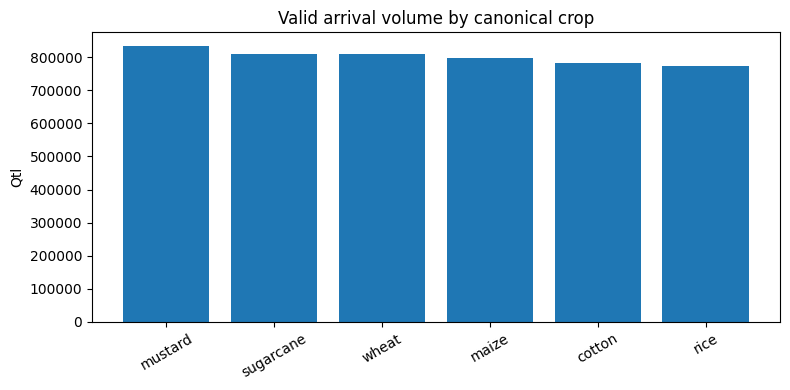

In [13]:
# Arrival volume distribution by canonical crop.
plot_df = arr_clean.loc[arr_clean.quantity_status.eq("VALID")].groupby("crop_name", as_index=False)["arrival_quantity_qtl"].sum().sort_values("arrival_quantity_qtl", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(plot_df["crop_name"], plot_df["arrival_quantity_qtl"])
ax.set_title("Valid arrival volume by canonical crop")
ax.set_ylabel("Qtl")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

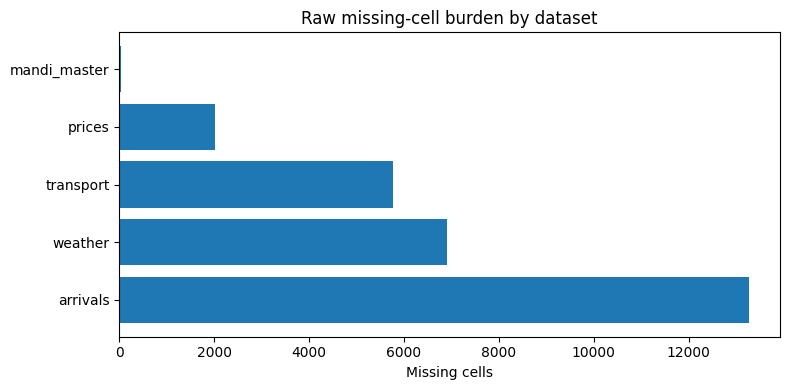

In [14]:
# Missingness heatmap for the raw source tables, summarized as counts.
missing_totals = pd.Series({name: int(df.isna().sum().sum()) for name, df in frames.items()}).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_totals.index, missing_totals.values)
ax.set_title("Raw missing-cell burden by dataset")
ax.set_xlabel("Missing cells")
plt.tight_layout()
plt.show()

## 12. Re-run the production cleaners and record the final row audit

This closes the notebook by connecting the forensic investigation to the same cleaning functions used by the production pipeline. No notebook-only cleaning rules are introduced.

In [15]:
cleaners = {
    "arrivals": clean_arrivals,
    "prices": clean_prices,
    "transport": clean_transport,
    "weather": clean_weather,
    "mandi_master": clean_mandi_master,
}
final_audit = []
for name, cleaner in cleaners.items():
    raw = frames[name]
    cleaned = cleaner(raw)
    final_audit.append({
        "dataset": name,
        "raw_rows": len(raw),
        "cleaned_rows": len(cleaned),
        "removed": len(raw) - len(cleaned),
    })
final_audit = pd.DataFrame(final_audit)
final_audit.loc[len(final_audit)] = ["TOTAL", final_audit.raw_rows.sum(), final_audit.cleaned_rows.sum(), final_audit.removed.sum()]
print(final_audit.to_string(index=False))

     dataset  raw_rows  cleaned_rows  removed
    arrivals     25750         25000      750
      prices     12000         12000        0
   transport     10400         10000      400
     weather     15000         15000        0
mandi_master        60            57        3
       TOTAL     63210         62057     1153


## Engineering conclusions

1. **Do not trust raw strings:** crop names, IDs, prices, units and timestamps require normalization before analysis.
2. **Do not invent recoveries:** missing arrival units stay analytically invalid because the original unit is unknowable.
3. **Preserve auditability:** invalid negative transit/rainfall values are flagged rather than silently rewritten.
4. **Keep fact tables separate when overlap is sparse:** forcing an exact-date join would create misleadingly complete charts.
5. **Reuse production cleaners:** the notebook documents and demonstrates the same functions used by DuckDB/database build.
6. **Treat synthetic geography as an assumption:** weather district attribution is tracked separately and is not presented as real mandi geography.

These decisions are the reason DatOps can explain not only **what** the dashboard shows, but also **why a record was allowed into a metric**.